In [14]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path

In [15]:
RNG=np.random.default_rng(2025)
num_dims=5
num_obs=50
mu_prior_mean=0
mu_prior_std=1
likelihood_std=1

In [16]:
# simulator
def prior():
    mu = RNG.normal(loc=mu_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    x =RNG.normal(loc=mu, scale=likelihood_std, size=(num_obs, num_dims))
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [17]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [18]:
# networks
summary_net = bf.networks.DeepSet(summary_dim=30,activation='relu')
inference_net = bf.networks.CouplingFlow(depth=5,transform="spline",widths=(128,128),activation="relu",dropout=0.05)

In [19]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize=None
                                          )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4))

In [20]:
history = workflow.fit_online(epochs=100,batch_size=64,num_batches_per_epoch=200)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 4.6849
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 3.1153
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 2.2559
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 1.8346
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 1.2825
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - loss: 1.0046
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 75ms/step - loss: 0.5055
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - loss: 0.0742
Epoch 9/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 69ms/step - loss: -0.0963
Epoch 10/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: -0.3214
Epoch 11/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: -0.5877
Epoch 12/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step - loss: -0.6249
Epoch 13/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - loss: -0.8190
Epoch 14/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - loss: -0.9151
Epoch 15/100

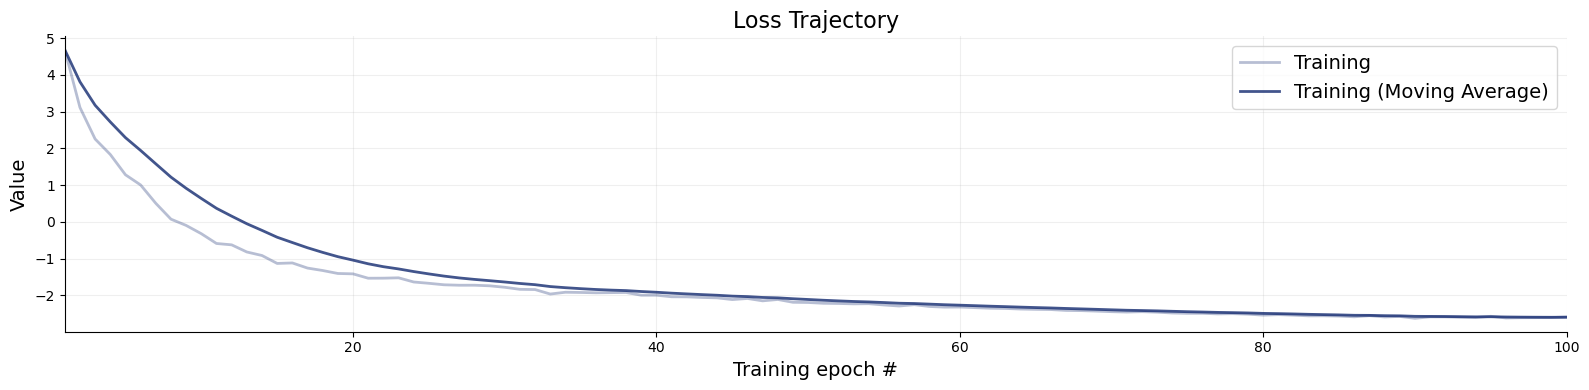

In [21]:
f=bf.diagnostics.plots.loss(history)

In [22]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()


dict_keys(['mu'])

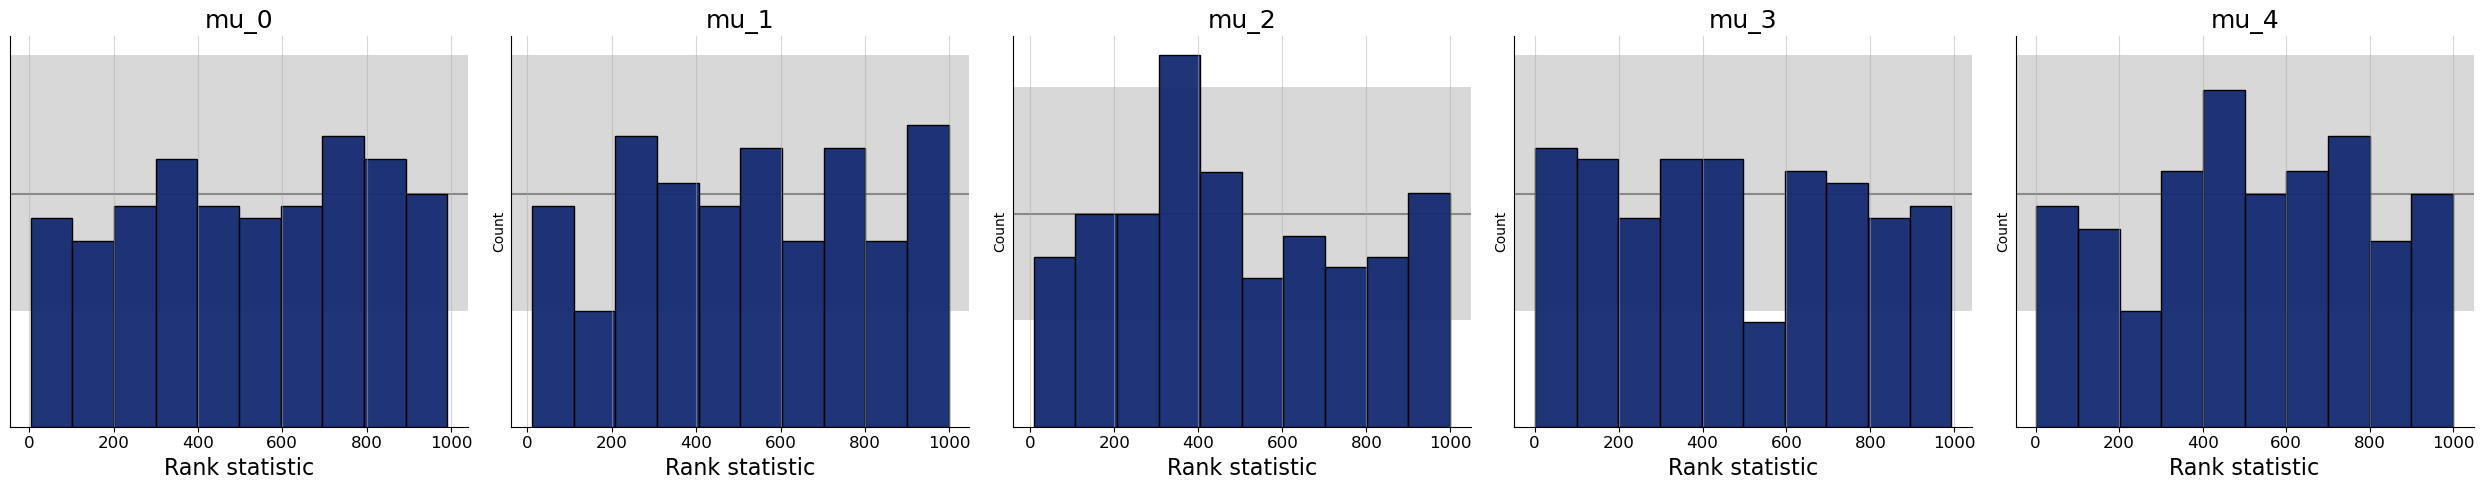

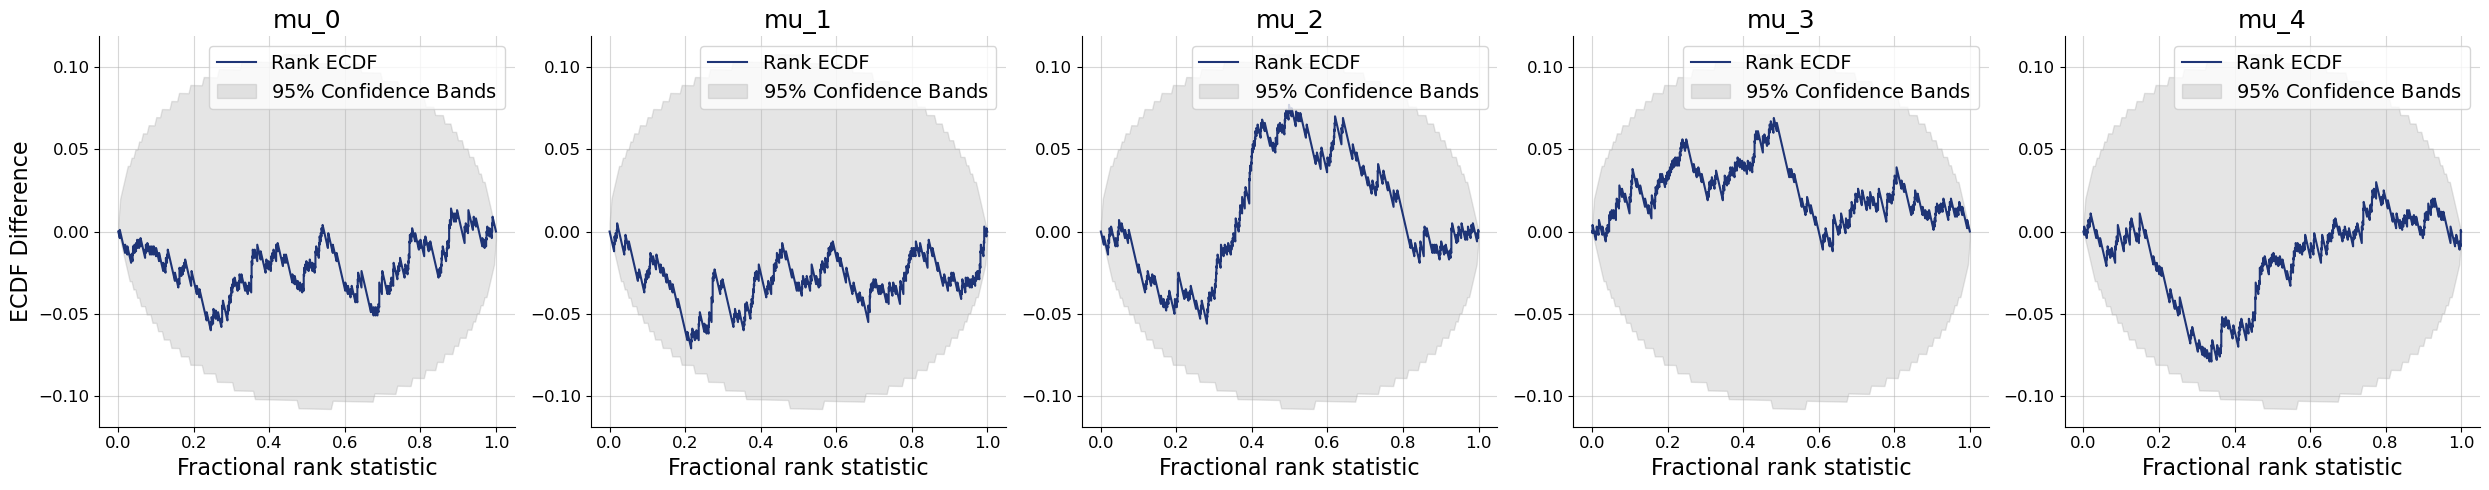

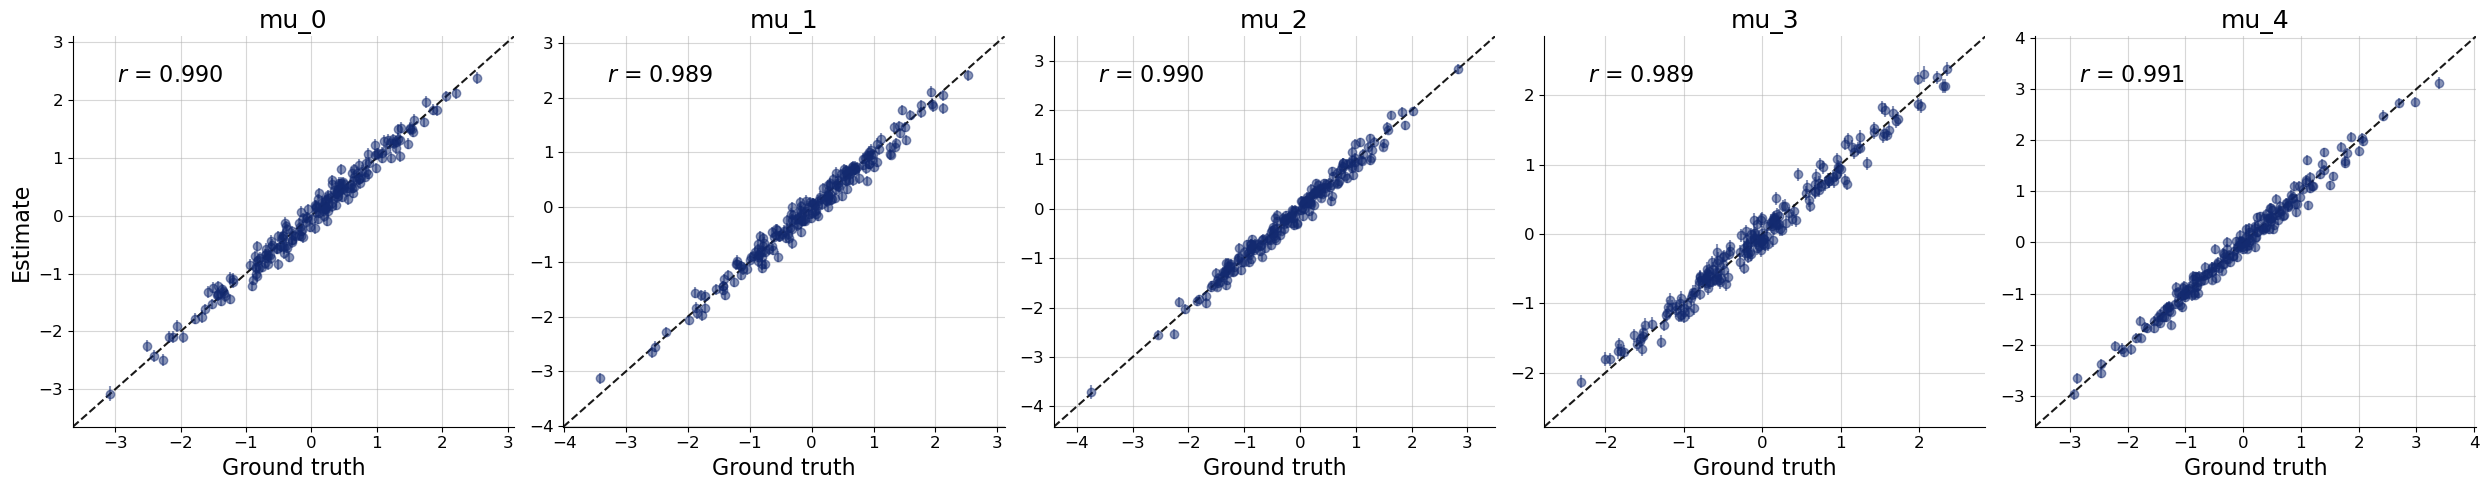

In [23]:
f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [24]:
# Save the trained approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "m1.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

In [25]:
# load approximator
filepath = Path("/Users/mandyking/benchmark/benchmark/examples/gaussian/networks") / "m1.keras"
approximator = keras.saving.load_model(filepath)

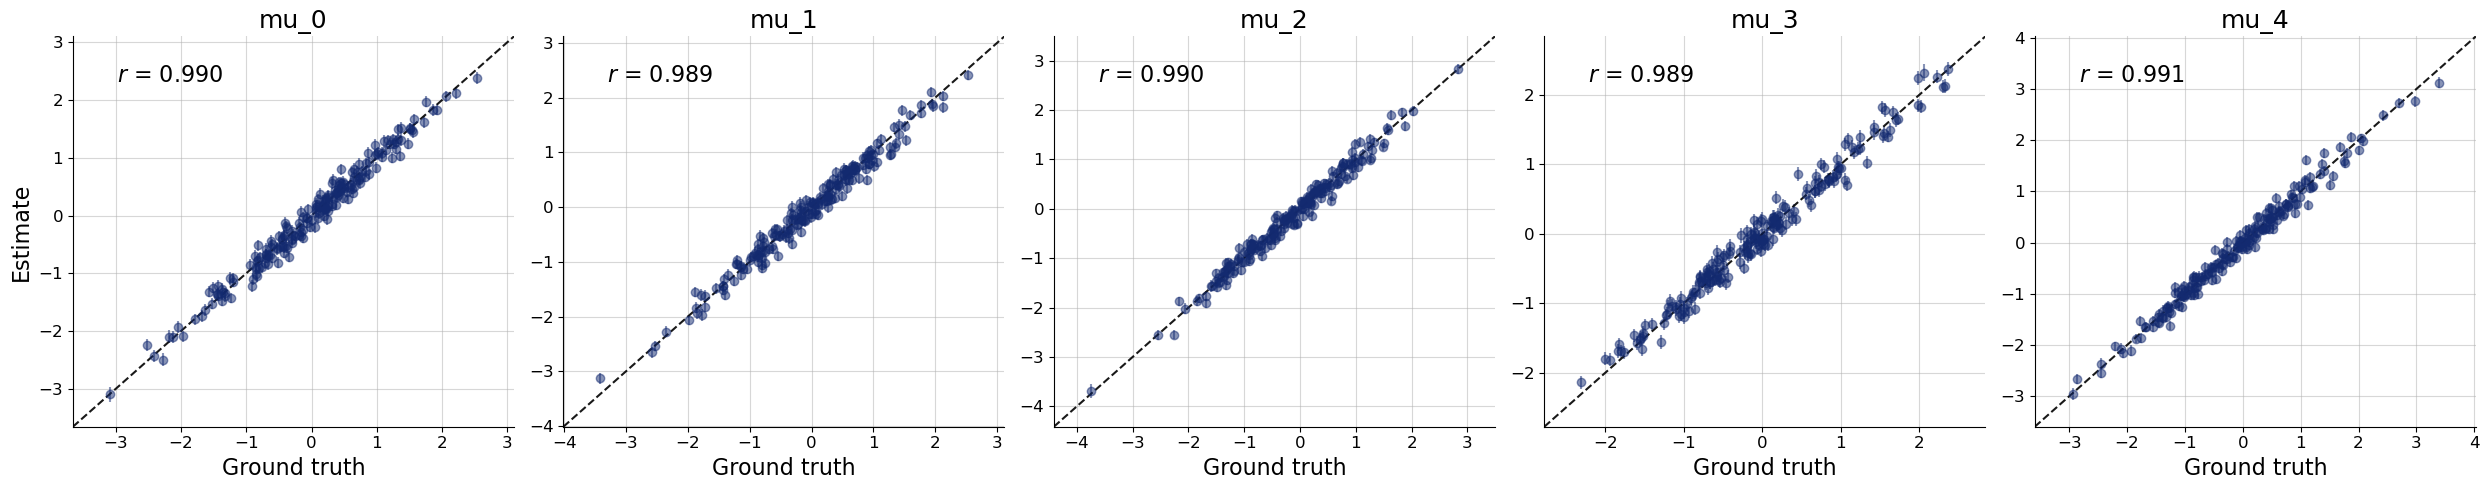

In [26]:
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)